In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

# How many students are in the dataset?

In [4]:
noOfStudents = len(df)
noOfStudents

1000

# What is the average score for each subject?

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
math_avg = df['math score'].mean()
reading_avg = df['reading score'].mean()
writing_avg = df['writing score'].mean()

print("Math Average:", math_avg)
print("Reading Average:", reading_avg)
print("Writing Average:", writing_avg)

Math Average: 66.089
Reading Average: 69.169
Writing Average: 68.054


## Visualize

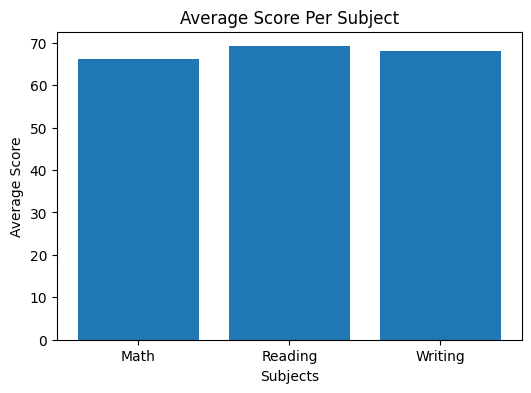

In [25]:
subjects = ["Math", "Reading", "Writing"]
subjectsAvg = [math_avg, reading_avg, writing_avg]

plt.figure(figsize=(6,4))
plt.bar(subjects, subjectsAvg)

plt.title("Average Score Per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.show()

# Who are the Top 5 performing students?

In [9]:
total_marks = df["math score"] + df["reading score"] + df["writing score"]
df["Total Marks"] = total_marks
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [14]:
sortedDf = df.sort_values(by="Total Marks", ascending=False)
sortedDf.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Marks
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
712,female,group D,some college,standard,none,98,100,99,297


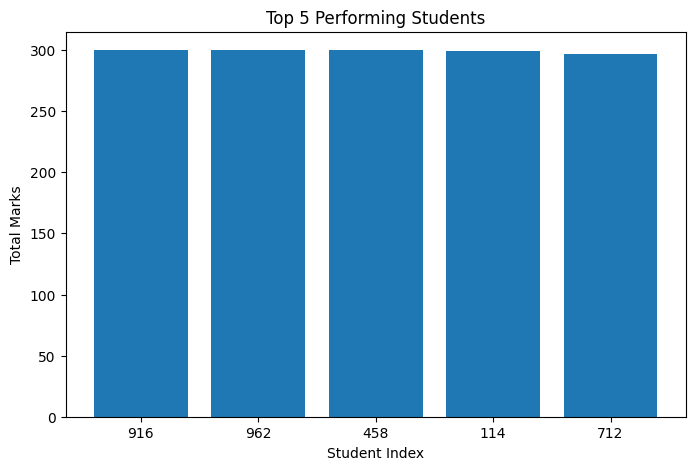

In [26]:
top5 = sortedDf.head()

plt.figure(figsize=(8,5))
plt.bar(top5.index.astype(str), top5["Total Marks"])

plt.title("Top 5 Performing Students")
plt.xlabel("Student Index")
plt.ylabel("Total Marks")

plt.show()

# Which students need improvement?

In [15]:
sortedDf.tail(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Marks
211,male,group C,some college,free/reduced,none,35,28,27,90
787,female,group B,some college,standard,none,19,38,32,89
338,female,group B,some high school,free/reduced,none,24,38,27,89
601,female,group C,high school,standard,none,29,29,30,88
76,male,group E,some high school,standard,none,30,26,22,78
17,female,group B,some high school,free/reduced,none,18,32,28,78
327,male,group A,some college,free/reduced,none,28,23,19,70
596,male,group B,high school,free/reduced,none,30,24,15,69
980,female,group B,high school,free/reduced,none,8,24,23,55
59,female,group C,some high school,free/reduced,none,0,17,10,27


In [35]:
# or
average_total = df["Total Marks"].mean()
studentsNeedImpove = df[df["Total Marks"] < average_total]
studentsNeedImpove

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Marks
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
7,male,group B,some college,free/reduced,none,40,43,39,122
8,male,group D,high school,free/reduced,completed,64,64,67,195
9,female,group B,high school,free/reduced,none,38,60,50,148
10,male,group C,associate's degree,standard,none,58,54,52,164
...,...,...,...,...,...,...,...,...,...
986,female,group C,associate's degree,standard,none,40,59,51,150
988,female,group A,some high school,free/reduced,none,44,45,45,134
994,male,group A,high school,standard,none,63,63,62,188
996,male,group C,high school,free/reduced,none,62,55,55,172


# Which subject has the highest class average?

In [24]:
subjects = ["Math", "Reading", "Writing"]
subjectsAvg = [math_avg, reading_avg, writing_avg]

highest = max(subjectsAvg)
index = subjectsAvg.index(highest)

print(subjects[index], highest)

Reading 69.169


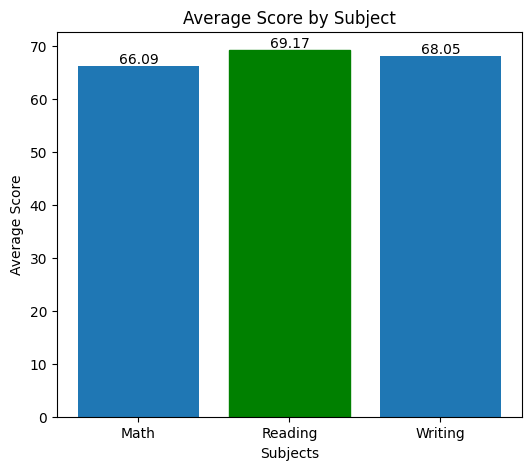

In [38]:
plt.figure(figsize=(6,5))

bars = plt.bar(subjects, subjectsAvg)

bars[index].set_color("green")

plt.title("Average Score by Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

for i, avg in enumerate(subjectsAvg):
    plt.text(i, avg + 0.5, f"{avg:.2f}", ha="center")

plt.show()

# Analysis of Dataset

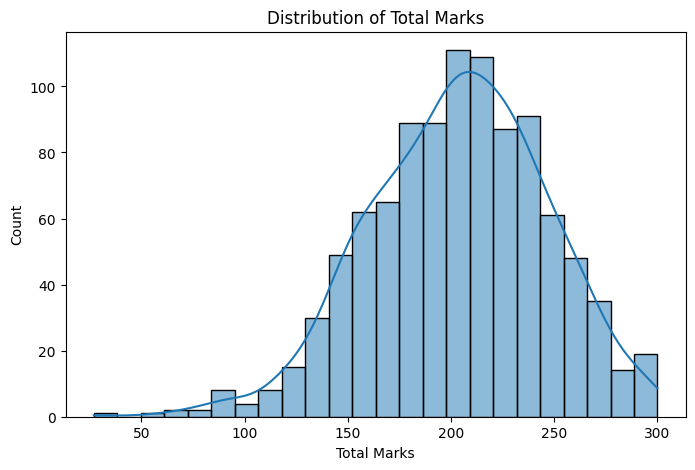

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total Marks"], kde=True)

plt.title("Distribution of Total Marks")
plt.xlabel("Total Marks")

plt.show()

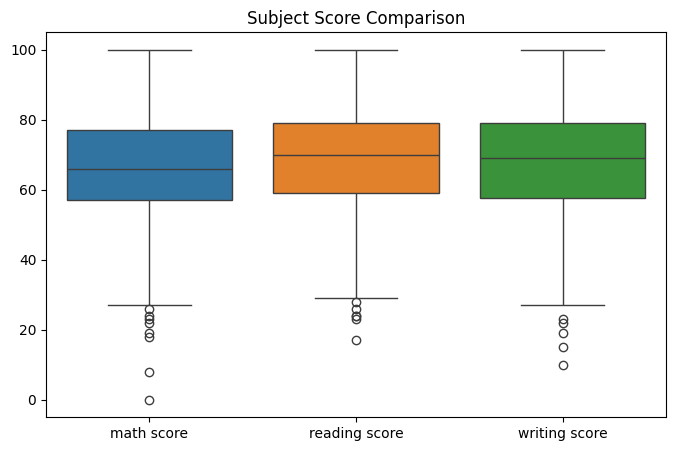

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["math score","reading score","writing score"]])

plt.title("Subject Score Comparison")

plt.show()

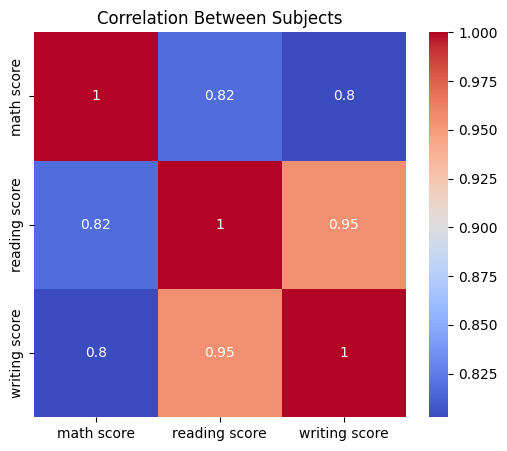

In [29]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["math score","reading score","writing score"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Subjects")

plt.show()

# Gender-wise Performance

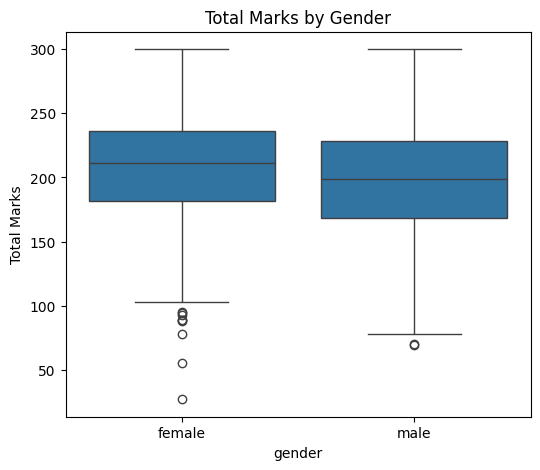

In [31]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="gender",
    y="Total Marks",
    data=df
)

plt.title("Total Marks by Gender")

plt.show()

#Gender Distribution

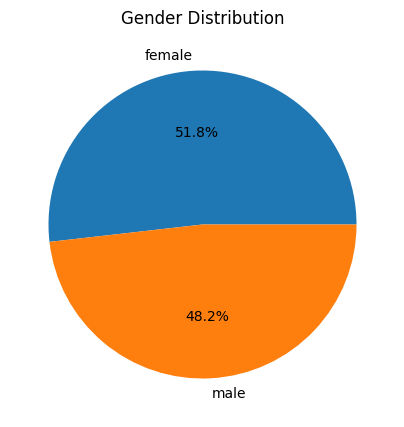

In [32]:
plt.figure(figsize=(5,5))

gender = df["gender"].value_counts()

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()


# Check categoies of parental level of education with count

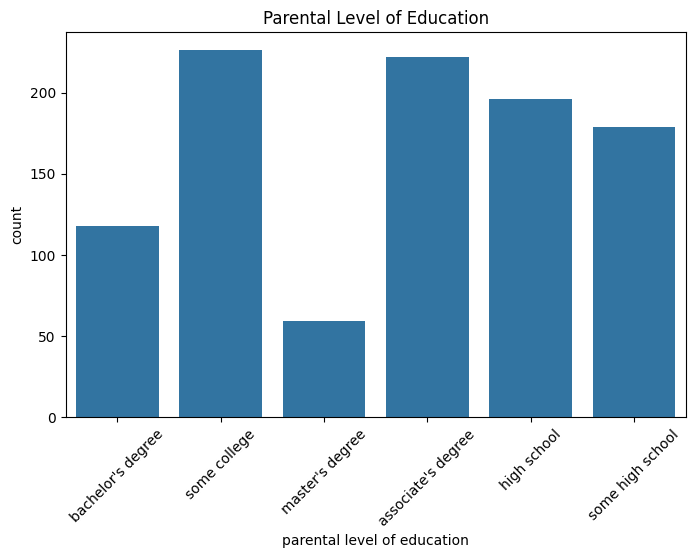

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x="parental level of education",
    data=df
)

plt.xticks(rotation=45)
plt.title("Parental Level of Education")

plt.show()

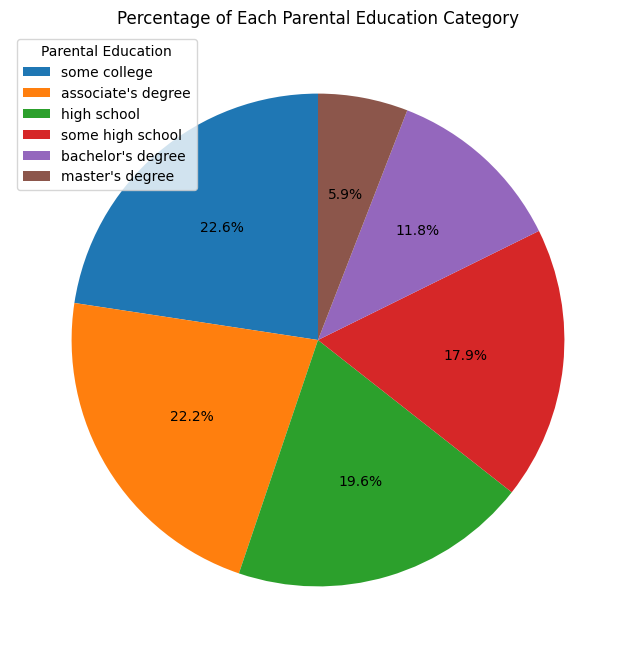

In [34]:
education = df["parental level of education"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    education,
    autopct="%1.1f%%",
    startangle=90
)

plt.legend(
    education.index,
    title="Parental Education",
    loc="best"
)

plt.title("Percentage of Each Parental Education Category")

plt.show()